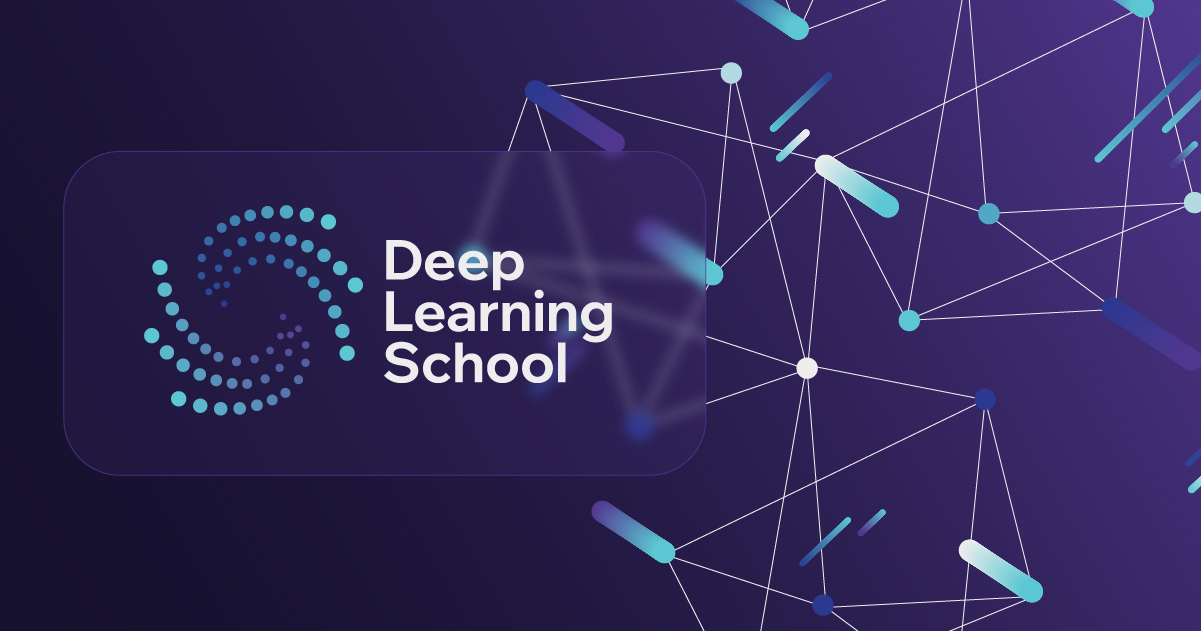

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Линейные алгоритмы</b></h3>


В этой домашке вы напишите свой класс логистической регрессии для бинарной классификации, а также логистическую регрессию с регуляризацией.

In [2]:
import numpy as np
import pandas as pd
import scipy.linalg as sla
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [3]:
np.random.seed(42)

# Градиентный спуск: повторение

Рассмотрим функцию от двух переменных
$f(\vec{r}) = f(x, y) = \sin^2 x + \sin^2 y$  



In [12]:
def f(x):
    """
    :param r: np.array(np.float) вектор длины 2
    :return: np.float

    На вход функции мы подаем двумерный массив: r = [x,y]
    Используем функцию np.sin() (https://numpy.org/doc/stable/reference/generated/numpy.sin.html) и оператор возведения в степень ** (https://numpy.org/doc/stable/reference/generated/numpy.power.html), которые применяются к массивам поэлементно
    """
    return np.sum(np.sin(x)**2)

Обратите внимание, что $r$ - numpy-array вектор длины 2.

***Reminder:***  
Что мы хотим? Мы хотим найти минимум этой функции (в машинном обучении мы обычно хотим найти минимум **функции потерь**, например, [MSE](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error)), а точнее найти $x_0$ и $y_0$ такие, что при них значение $f(x_0,y_0)$ минимально, то есть *точку экстремума*.  
  
Как мы будем искать эту точку? Используем методы оптимизации (в нашем случае - *минимизации*). Одним из таких методов и является **градиентный спуск**.

## Задание 1
Реализуйте функцию, которая будет осуществлять градиентный спуск для функции $f$:

Но для начала вспомним, что такое градиент и как его посчитать.

**Градиент функции** — это *вектор*, который указывает направление наибольшего возрастания функции. Для функции от двух переменных $f(x,y)$ градиент вычисляется как:

$\nabla f(x, y) = \left( \dfrac{\partial f}{\partial x}, \dfrac{\partial f}{\partial y} \right)$

Здесь:

$\dfrac{\partial f}{\partial x}$ — частная производная функции $f$ по переменной $x$,

$\dfrac{\partial f}{\partial y}$ — частная производная функции $f$ по переменной $y$.

*Пример подсчета градиента:*

$f(x, y) = x^2 + 3xy+y^2$

$\dfrac{\partial f}{\partial x} = 2x+3y$

$\dfrac{\partial f}{\partial y} = 2y+3x$

$\nabla f(x, y) = \left( \dfrac{\partial f}{\partial x}, \dfrac{\partial f}{\partial y} \right) = \left(2x+3y, 2y+3x\right)$

Более подробно про вычисление градиента можно прочитать, например, [здесь](http://mathprofi.ru/proizvodnaja_po_napravleniju_i_gradient.html).


*Примечание:* В этом задании вам нужно посчитать частные производные **аналитически** и **переписать их в код**, а не считать производные численно, например, через отношение приращения функции к приращению аргумента -- в этих двух случаях ответы могут различаться, поэтому будьте внимательны.

In [13]:
# Сначала реализуем функцию, вычисляющую градиент

def grad_f(x):
    """
    Градиент функциии f, определенной выше.
    :param r: np.array[2]: float вектор длины 2
    :return: np.array[2]: float вектор длины 2
    """
    return np.sin(2*x)

In [14]:
# Проверим, что градиент принимает вектор из двух чисел и выдает на этой точке верное значение
assert np.allclose(grad_f(np.array([1, 2])),
                   np.array([0.90929743, -0.7568025])), "Что-то не так!"

In [15]:
def grad_descent_2d(f, grad_f, lr, num_iter=100, x0=None):
    """
    функция, которая реализует градиентный спуск для функции f от двух переменных.
        :param f: скалярная функция двух переменных
        :param grad_f: функция, возвращающая градиент функции f (устроена так, как реализованная вами выше grad_f)
        :param lr: learning rate алгоритма
        :param num_iter: количество итераций градиентного спуска
        :param r0: начальное значение аргумента f(r), которое мы инициируем случайно или можем передать как аргумент в функцию grad_descent_2d()

        :return: np.array[num_iter, 2] пары вида (r, f(r))
    """
    if x0 is None:
        x0 = np.random.random(2)

    # в процессе градиентного спуска будем сохранять в переменную history значения
    history = []

    # итерация цикла -- шаг градиентного спуска
    curr_r = x0.copy()
    for iter_num in range(num_iter):
        entry = np.hstack((curr_r, f(curr_r)))
        history.append(entry)

        # curr_r - текущие значения аргумента в процессе градиентного спуска
        curr_r -= lr * grad_f(curr_r)

    return np.vstack(history)

### Тестируем написанную функцию

In [16]:
steps = grad_descent_2d(f, grad_f, lr=0.1, num_iter=20)

Визуализируем точки градиентного спуска на 3D-графике нашей функции. Звездочками будут обозначены точки (тройки $x, y, f(x, y)$), по которым Ваш алгоритм градиентного спуска двигался к минимуму.

(Для того, чтобы нарисовать этот график, мы и сохраняли значения $cur\_x, cur\_y, f(cur\_x, cur\_y)$ в `steps` в процессе спуска)

Для работы с 3D визуализацией удобно пользоваться библиотекой **[plotly](https://habr.com/ru/articles/502958/)**. Она позволяет легко строить интерактивные 3D-графики. Вы можете вращать и приближать полученную фигуру при помощи мышки!

Если у Вас правильно написана функция `grad_descent_2d`, то крестики на картинке должны сходиться к одной из точек минимума функции. Вы можете менять начальные приближения алгоритма, значения `lr` и `num_iter` и получать разные результаты.

In [17]:
# Посмотрим, что из себя предствавляет вывод функции:
steps

# Для большей наглядности можно сконвертировать данные в формат pandas.DataFrame и добавить подписи к столбцам. Для этого раскоментируйте код ниже:
#pd.DataFrame(data = steps, columns=['x', 'y', 'f([x,y])'])

array([[3.74540119e-01, 9.50714306e-01, 7.96162814e-01],
       [3.06443570e-01, 8.56130580e-01, 6.61501405e-01],
       [2.48920419e-01, 7.57129527e-01, 5.32438585e-01],
       [2.01167461e-01, 6.57289308e-01, 4.13213611e-01],
       [1.62010673e-01, 5.60553766e-01, 3.08675973e-01],
       [1.30172552e-01, 4.70495524e-01, 2.22355696e-01],
       [1.04431147e-01, 3.89681303e-01, 1.55185446e-01],
       [8.36964420e-02, 3.19398688e-01, 1.05582063e-01],
       [6.70352177e-02, 2.59775649e-01, 7.04659717e-02],
       [5.36683031e-02, 2.10126580e-01, 4.63846811e-02],
       [4.29552413e-02, 1.69327420e-01, 3.02428152e-02],
       [3.43747570e-02, 1.36105556e-01, 1.95917748e-02],
       [2.75052200e-02, 1.09219378e-01, 1.26378615e-02],
       [2.20069501e-02, 8.75488032e-02, 8.12945761e-03],
       [1.76069810e-02, 7.01283780e-02, 5.21990623e-03],
       [1.40863125e-02, 5.61486426e-02, 3.34776943e-03],
       [1.12694227e-02, 4.49425016e-02, 2.14546343e-03],
       [9.01572898e-03, 3.59660

In [18]:
import numpy as np
import plotly.graph_objects as go

# Создание сетки
border = 1.5 # Меняйте значения border, чтобы увеличивать или уменьшать область
X, Y = np.meshgrid(np.linspace(-border, border, 100), np.linspace(-border, border, 100))
Z = np.array([f(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

# Создание 3D-графика
fig = go.Figure(data=[
    go.Surface(z=Z, x=X, y=Y, colorscale='Viridis')
])

# Добавление линии и маркеров
fig.add_trace(go.Scatter3d(
    x=steps[:, 0],
    y=steps[:, 1],
    z=steps[:, 2],
    mode='lines+markers',
    marker=dict(size=8, color='red', symbol='cross'),
    line=dict(color='black', width=5)
))

# Настройка осей
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        zaxis=dict(range=[-1, 5]),  # Установка пределов для Z
        aspectratio=dict(x=1, y=1, z=0.7)  # Соотношение сторон
    ),
    margin=dict(l=0, r=0, b=0, t=0)  # Удаление отступов
)

# Отображение графика
fig.show();

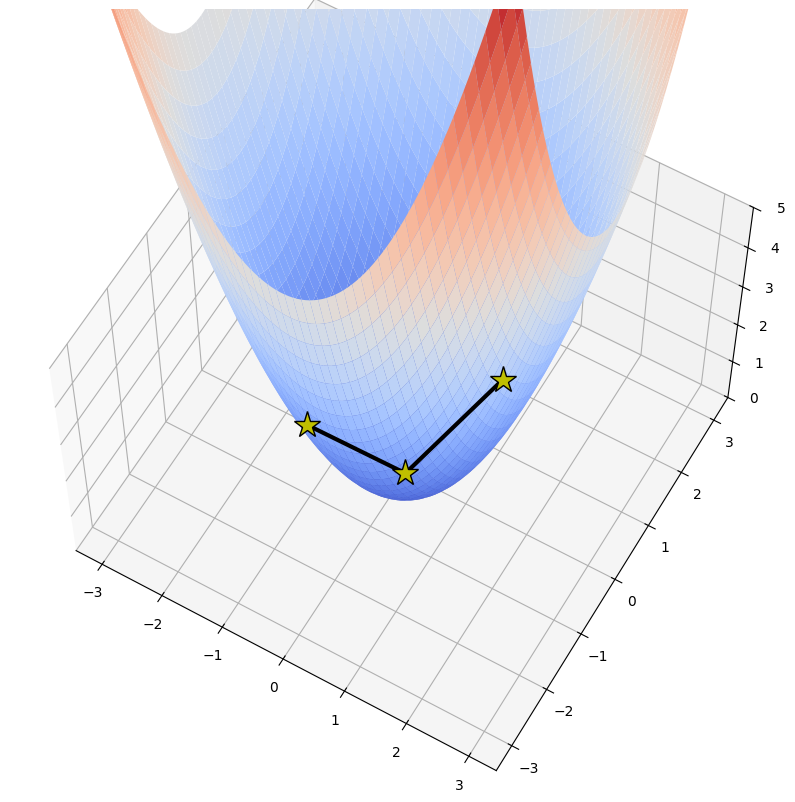

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Нужен для 3D
from matplotlib import cm


# Ваша функция f (пример)
def f(point):
    x, y = point
    return x**2 + y**2

# Сетка
X, Y = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
zs = np.array([f(np.array([x, y])) for x, y in zip(np.ravel(X), np.ravel(Y))])
Z = zs.reshape(X.shape)

# Создание фигуры и 3D-оси (вариант 1: add_subplot)
#fig = plt.figure(figsize=(16, 10))
#ax = fig.add_subplot(111, projection='3d')

# Или вариант 2: plt.subplots
fig, ax = plt.subplots(figsize=(16, 10), subplot_kw={'projection': '3d'})


# Рисуем поверхность
ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, zorder=2)


# Если нужен путь (steps), определите его заранее
steps = np.array([[-1, -1, f([-1, -1])],
                 [0, 0, f([0, 0])],
                 [1, 1, f([1, 1])]])
ax.plot(xs=steps[:, 0], ys=steps[:, 1], zs=steps[:, 2],
        marker='*', markersize=20, zorder=3,
        markerfacecolor='y', lw=3, c='black')


ax.set_zlim(0, 5)
ax.view_init(elev=60)
plt.show()

Посмотрим на график значений функции от шага

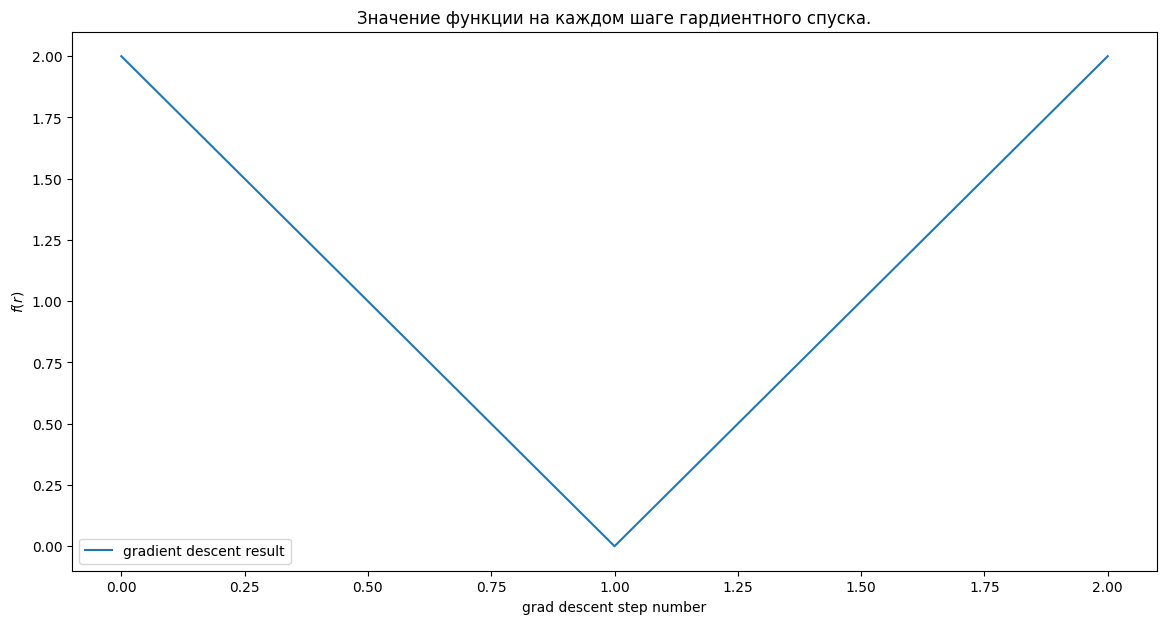

In [25]:
plt.figure(figsize=(14,7))
plt.xlabel('grad descent step number')
plt.ylabel('$f(r)$')
plt.title('Значение функции на каждом шаге гардиентного спуска.')

f_values = list(map(lambda x: x[2], steps))
plt.plot(f_values, label='gradient descent result')
plt.legend()

Когда вы используете градиентный спуск всегда нужно проверять, сошелся ли он. К сожалению для большинства моделей не получится построить 3D график, поэтому обязательно нужно смотреть на то, как менялся лосс на каждом шаге градиентного спуска.

# Генератор батчей

Обычно генерация батчей отличается от той, которую мы использовали в семинаре. Мы выбирали *batch_size* случайных строчек на каждом шаге, но у такого подхода есть минусы. Основной заключается в том, что некоторые строчки из обучающего датасета могут попадаться значительно реже, чем другие.

Чтобы это исправить обучение делят на эпохи. Мы хотим, чтобы в течение одной эпохи модель обучилась на каждом примере один раз. Для этого нужно перемешать строчки в датасете и каждый раз брать очередные *batch_size* строчек.

Может так получится, что размер датасета не делится на *batch_size*, тогда последний батч будет состоять из нескольких последних строк и его размер будет меньше, чем *batch_size*. Такой батч иногда выкидывают и просто не используют. Именно так вам нужно поступить в этом задании.

## Задание 2

Напишите генератор батчей, который будет принимать на вход признаки, ответы и размер батча. Генератор должен возвращать tuple из ($X_{batch}$, $y_{batch}$). Если размер датасета не делится на batch_size, то **последний маленький батч возвращать не нужно**.

Подробнее про Python генераторы можно прочитать здесь:

[Документация](https://wiki.python.org/moin/Generators)

[Описание на русском](https://pythoner.name/list-generator)

Чтобы не перемешивать сам датасет воспользуйтесь `np.random.permutation(len(X))`, выходом которой будет последовательность чисел 0, ..., len(X) - 1, переставленных в случайном порядке (см. https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html). Для нарезки на батчи берите индексы для X и y из этой переупорядоченной последовательности, которая в коде ниже обозначена как perm.

Для того, чтобы вспомнить как работать с индексами массивов numpy, можно почитать документацию по Indexing on ndarrays, в частности раздел по Integer array indexing https://numpy.org/doc/stable/user/basics.indexing.html#integer-array-indexing.


In [30]:
def generate_batches(X, y, batch_size):
    """
    param X: np.array[n_objects, n_features] --- матрица объекты-признаки
    param y: np.array[n_objects] --- вектор целевых переменных
    """
    assert len(X) == len(y)
    np.random.seed(42)
    X = np.array(X)
    y = np.array(y)
    perm = np.random.permutation(len(X))
    n = len(X)
    n_batches = n // batch_size

    for batch_start in range(0, n_batches * batch_size, batch_size):
        batch_index = perm[batch_start:batch_start + batch_size]
        X_batch = X[batch_index]
        y_batch = y[batch_index]
        yield X_batch, y_batch

### Тестируем написанную функцию

Проверим, что наш генератор батчей перемешивает датасет и каждый элемент встречается один раз:

In [31]:
X_fake = np.arange(100)[:, np.newaxis]
y_fake = np.arange(100) + 1000

X_reconstructed, y_reconstructed = [], []
for X_batch, y_batch in generate_batches(X_fake, y_fake, 10):
    X_reconstructed.append(X_batch)
    y_reconstructed.append(y_batch)

X_reconstructed = np.concatenate(X_reconstructed)
y_reconstructed = np.concatenate(y_reconstructed)

assert (X_fake != X_reconstructed).all(), "Что-то не так!"
assert (y_fake != y_reconstructed).all(), "Что-то не так!"

assert (np.sort(X_reconstructed, axis=0) == X_fake).all(), "Что-то не так!"

Попробуем теперь *batch_size*, не делящий размер датасета.

In [32]:
X_fake = np.arange(100)[:, np.newaxis]
y_fake = np.arange(100) + 1000

num_batches = 0
for X_batch, y_batch in generate_batches(X_fake, y_fake, 7):
    num_batches += 1

assert num_batches == len(X_fake) // 7, "Что-то не так!"

# Обычная логистическая регрессия
В этом пункте вы напишете класс логистической регрессии. Пока мы не будем добавлять в функцию потерь регуляризационные слагаемые.

Вам необходимо будет воспользоваться оптимизацией с помощью SGD, используя генератор батчей, который вы написали выше.

## Задание 3
Реализуйте методы ``fit`` и ``get_grad`` класса ``MyLogisticRegression``.


Напоминаем формулы:

$$Loss(y, p) = -\sum_{i=1}^{\ell} (y_i \log (p_i) + (1 - y_i) \log (1 - p_i))$$


$$ \frac{\partial L}{\partial w} = X^T (p - y)$$


In [38]:
def logit(x, w):
    return x @ w

def sigmoid(h):
    return 1. / (1 + np.exp(-h))

In [39]:
class MyLogisticRegression(object):
    def __init__(self):
        self.w = None

    def fit(self, X, y, epochs=10, lr=0.1, batch_size=100):
        l, n = X.shape
        if self.w is None:
            np.random.seed(42)
            # Вектор столбец в качестве весов
            self.w = np.random.randn(n + 1)

        X_train = np.concatenate((np.ones((l, 1)), X), axis=1)

        losses = []
        eps = 1e-8

        # Положите в лист losses лосс на каждом батче. Не нужно усреднять лосс по эпохе.

        for i in range(epochs):
            for X_batch, y_batch in generate_batches(X_train, y, batch_size):
                # В X_train уже добавлен вектор 1
                z = logit(X_batch, self.w)
                p = sigmoid(z)

                p_clip = np.clip(p, eps, 1 - eps)
                loss = -np.sum(y_batch * np.log(p_clip) + (1 - y_batch) * np.log(1 - p_clip))

                assert (np.array(loss).shape == tuple()), "Лосс должен быть скаляром!"

                losses.append(loss)

                grad = self.get_grad(X_batch, y_batch, p)
                self.w = self.w - lr * grad

        return losses

    def get_grad(self, X_batch, y_batch, predictions):
        """
        param X_batch: np.array[batch_size, n_features + 1] --- матрица объекты-признаки
        param y_batch: np.array[batch_size] --- батч целевых переменных
        param predictions: np.array[batch_size] --- батч вероятностей классов

        Принимает на вход X_batch с уже добавленной колонкой единиц.
        Выдаёт градиент функции потерь логистической регрессии
        как сумму градиентов функции потерь на всех объектах батча
        ВНИМАНИЕ! Нулевая координата вектора весов -- это BIAS, а не вес признака.
        Также не нужно ДЕЛИТЬ ГРАДИЕНТ НА РАЗМЕР БАТЧА:
        нас интересует не среднее, а сумма.
        В качестве оператора умножения матриц можно использовать @

        Выход -- вектор-столбец градиентов для каждого веса (np.array[n_features + 1])
        """

        error = (predictions - y_batch)
        grad_basic = X_batch.T @ error
        assert grad_basic.shape == (X_batch.shape[1],) , "Градиенты должны быть столбцом из k_features + 1 элементов"

        return grad_basic

    def predict_proba(self, X):
        l, n = X.shape
        X_ = np.concatenate((np.ones((l, 1)), X), axis=1)
        return sigmoid(logit(X_, self.w))

    def _predict_proba_internal(self, X):
        """
        Возможно, вы захотите использовать эту функцию вместо predict_proba, поскольку
        predict_proba конкатенирует вход с вектором из единиц, что не всегда удобно
        для внутренней логики вашей программы
        """
        return sigmoid(logit(X, self.w))

    def predict(self, X, threshold=0.5):
        return self.predict_proba(X) >= threshold

    def get_weights(self):
        return self.w.copy()
        # copy тут используется неспроста. Если copy не использовать, то get_weights()
        # выдаст ссылку на объект, а, значит, модифицируя результат применения функции
        # get_weights(), вы модифицируете и веса self.w. Если вы хотите модифицировать веса,
        # (например, в fit), используйте self.w

    def __loss(self, y, p):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

### Тестируем написанную функцию


In [40]:
m = MyLogisticRegression()
X = np.array([[1, 3, 4], [1, -5, 6], [-3, 5, 3]])
X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
y = np.array([1, 0, 1])
preds = np.array([.55, .22, .85])
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([-0.38,  0.22, -3.2 , -0.93])), "Что-то не так!"

In [41]:
np.random.seed(42)
m = MyLogisticRegression()
X = np.random.rand(100,3)
y = np.random.randint(0, 1, size=(100,))
preds = np.random.rand(100)
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([23.8698149, 25.27049356, 24.4139452])), "Что-то не так!"

# Логистическая регрессия с $l_1$ и $l_2$ регуляризацией (elastic net).

Ваша задача -- написать класс логистической регрессии с обеими регуляризациями и оптимизацией с помощью SGD, используя генератор батчей, который вы написали выше.

Обратите внимание, что реализация ElasticNet отличается от реализации LogisticRegression только функцией потерь для оптимизации. Поэтому функции, которые будет отличаться у двух методов, это ``self.get_grad()`` и ``self.__loss()``.

Поэтому в данном случае естественно применить паттерн *наследования*. Весь синтаксис наследования мы прописали за вас. Единственное, что вам осталось сделать, это переопределить методы ``get_grad()``  и ``self.__loss()`` в отнаследованном классе.

## Задание 4
Реализуйте метод ``get_grad()`` класса ``MyElasticLogisticRegression``

Формулы:

$$L_1 (w) = \alpha \sum_{j=1}^{n}|w_j| $$

$$L_2 (w) = \beta\sum_{j=1}^{n}w_j^2$$

$$\frac{\partial L_1}{\partial w_1} = \alpha \cdot \mathrm{sign}(w_1)$$

$$ \frac{\partial L_2}{\partial w_1} = 2\beta w_1$$


In [46]:
class MyElasticLogisticRegression(MyLogisticRegression):
    def __init__(self, l1_coef, l2_coef):
        self.l1_coef = l1_coef
        self.l2_coef = l2_coef
        self.w = None

    def __loss(self, y, p):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        loss = -np.sum(y * np.log(p + 1e-8) + (1 - y) * np.log(1 - p + 1e-8))

        loss_l1 = self.l1_coef * np.sum(np.abs(self.w[1:]))
        loss_l2 = self.l2_coef * np.sum(self.w[1:] ** 2)

        return loss + loss_l1 + loss_l2

    def get_grad(self, X_batch, y_batch, predictions):
        """
        Принимает на вход X_batch с уже добавленной колонкой единиц.
        Выдаёт градиент функции потерь логистической регрессии с регуляризаторами
        как сумму градиентов функции потерь на всех объектах батча + регуляризационное слагаемое
        ВНИМАНИЕ! Нулевая координата вектора весов -- это BIAS, а не вес признака.
        Bias в регуляризационные слагаемые не входит. Также не нужно ДЕЛИТЬ ГРАДИЕНТ НА РАЗМЕР БАТЧА:
        нас интересует не среднее, а сумма.

        Выход -- вектор-столбец градиентов для каждого веса (np.array[n_features + 1])
        """

        # YOUR CODE: компонент градиента из логрегрессии. Обнулять bias-компоненту этой составляющей градиента не нужно!
        error = (predictions - y_batch)
        grad_basic = X_batch.T @ error
        # YOUR CODE: компонент градиента из l_1-регуляризации (не забудьте обнулить компоненту с bias)
        grad_l1 = self.l1_coef * np.sign(self.w)
        grad_l1[0] = 0

        # YOUR CODE: компонент градиента из l_2-регуляризации (не забудьте обнулить компоненту с bias)
        grad_l2 = 2 * self.l2_coef * self.w
        grad_l2[0] = 0

        # Обнулять bias-компоненту вектора весов не нужно!

        assert grad_l1[0] == grad_l2[0] == 0, "Bias в регуляризационные слагаемые не входит!"
        assert grad_basic.shape == grad_l1.shape == grad_l2.shape == (X_batch.shape[1],) , "Градиенты должны быть столбцом из k_features + 1 элементов"

        return grad_basic + grad_l1 + grad_l2

### Тестирование
Протестируем написанную функцию:


In [47]:
m = MyElasticLogisticRegression(.2,.2)
X = np.array([[1, 3, 4], [1, -5, 6], [-3, 5, 3]])
X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
y = np.array([1, 0, 1])
preds = np.array([.55, .22, .85])
m.w = np.array([1,1,1,1])
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([-0.38,  0.82, -2.6 , -0.33])), "Что-то не так!"


In [48]:
np.random.seed(42)
m = MyElasticLogisticRegression(.2, .2)
X = np.random.rand(100,3)
X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
y = np.random.randint(0, 1, size=(100,))
preds = np.random.rand(100)
m.w = np.array([1,1,1,1])
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([49.11489408, 24.4698149, 25.87049356, 25.0139452])), "Что-то не так!"


## Смотрим, как работает наша модель
Протестируем на искусственных данных:

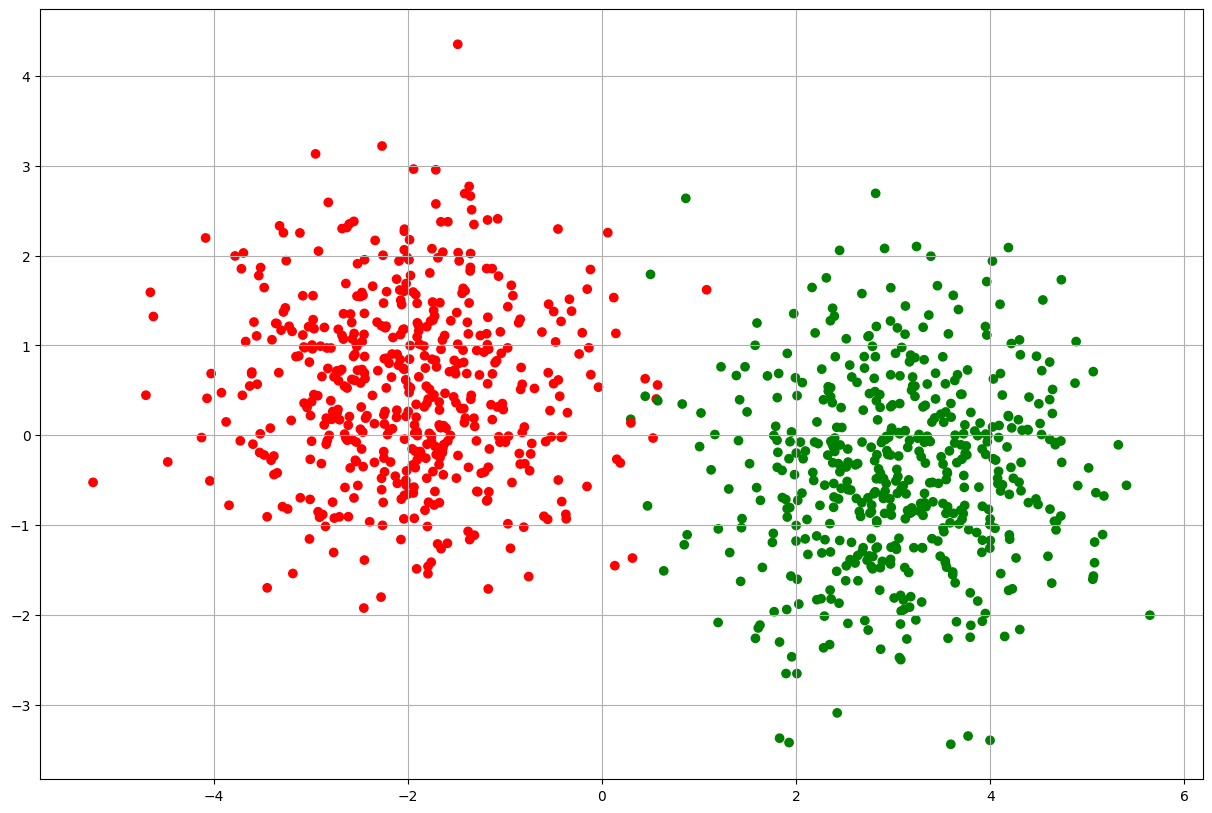

In [49]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000, centers=[[-2,0.5],[3,-0.5]], cluster_std=1, random_state=42)

colors = ("red", "green")
colored_y = np.zeros(y.size, dtype=str)

for i, cl in enumerate([0,1]):
    colored_y[y.ravel() == cl] = str(colors[i])

plt.figure(figsize=(15,10))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.grid()
plt.show();

In [50]:
clf = MyElasticLogisticRegression(0.1, 0.1)
clf.fit(X, y, epochs=1000)
w = clf.get_weights()

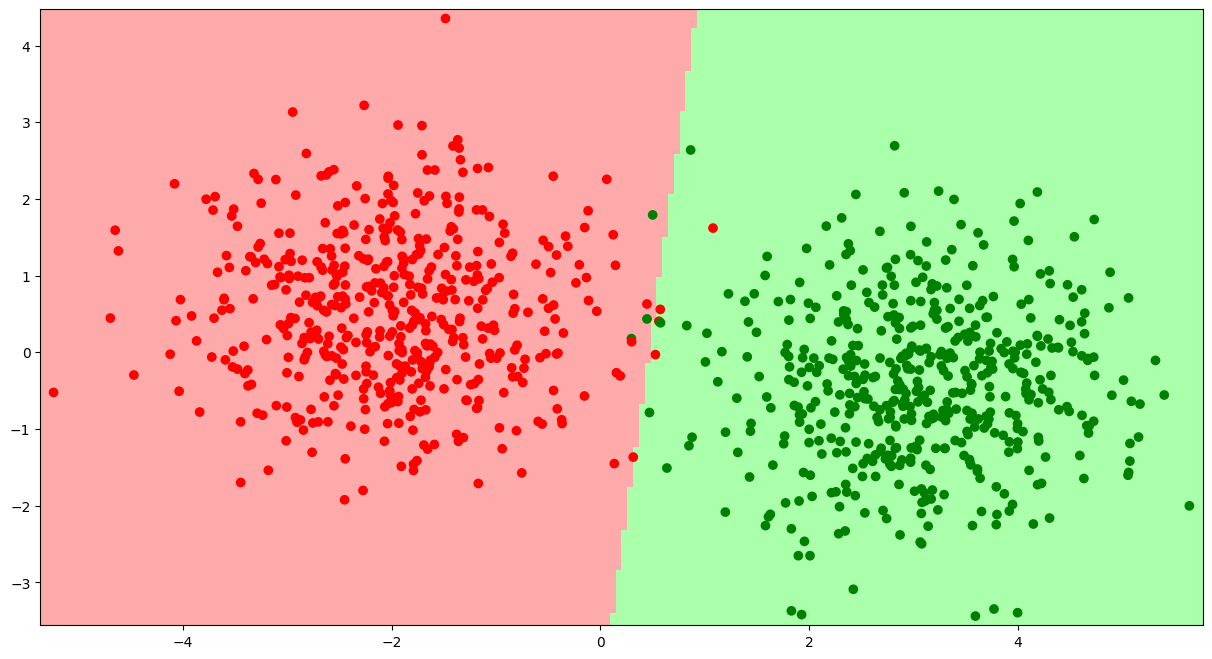

In [51]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(15,8))

eps = 0.1
xx, yy = np.meshgrid(np.linspace(np.min(X[:,0]) - eps, np.max(X[:,0]) + eps, 200),
                     np.linspace(np.min(X[:,1]) - eps, np.max(X[:,1]) + eps, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

plt.scatter(X[:, 0], X[:, 1], c=colored_y)

Теперь протестируем на датасете MNIST. Это очень простой класический датасет, на котором часто тестируются модели. С помощью нейронных сетей люди научились получать на нем качество 99.84%.

Датасет состоит из черно-белых картинок с цифрами. ![mnist-3.0.1.png](https://www.researchgate.net/profile/Steven_Young11/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Так как мы сделали классификатор для двух классов, то мы выберем из всех картинок только картинки 0 и 1, првратим их из двумерной матрицы в вектор и обучим нашу модель.

In [53]:
data = pd.read_csv('/content/sample_data/mnist_test.csv')
# файл лежит в директории с домашним заданием. Чтобы иметь возможность его
# открыть, загрузите его на колаб (панель слева, нажимаем значок "Файлы",
# выбираем "загрузить в сессионное хранилище", выбираем нужный файл)
data.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Данные выглядят как таблица, первая колонка которой это лейбел -- цифра, которая изображена на картинке, а следующие 784 колонки это значения от 0 до 255, описывающие все пиксели картинки 28х28. То есть нам не придется делать reshape и превращать матрицу в вектор, так как это уже сделано.

In [54]:
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Выберем только картинки, где изображен 0 и 1
X = X[(y == 0) | (y == 1)]
y = y[(y == 0) | (y == 1)]

Для оценки модели мы используем кросс валидацию.

In [57]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin

class SklearnElasticAdapter(BaseEstimator, ClassifierMixin):
    def __init__(self, l1_coef=0.0, l2_coef=0.0, lr=0.1, epochs=10, batch_size=100, threshold=0.5):
        self.l1_coef = l1_coef
        self.l2_coef = l2_coef
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.threshold = threshold
        self.model_ = None  # сюда положим твою модель после fit

    def fit(self, X, y):
        y = np.asarray(y).reshape(-1)  # sklearn любит (n,), не (n,1)

        self.model_ = MyElasticLogisticRegression(self.l1_coef, self.l2_coef)
        self.model_.fit(X, y, lr=self.lr, epochs=self.epochs, batch_size=self.batch_size)

        return self

    def predict(self, X):
        # твой predict, вероятно, возвращает bool — для accuracy это ок, но сделаем int
        return self.model_.predict(X, threshold=self.threshold).astype(int)

    def predict_proba(self, X):
        # sklearn ожидает (n_samples, 2): P(class0), P(class1)
        p1 = self.model_.predict_proba(X).reshape(-1)
        p0 = 1.0 - p1
        return np.vstack([p0, p1]).T


In [58]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

pipe = make_pipeline(
    StandardScaler(),
    SklearnElasticAdapter(
        l1_coef=1e-3,
        l2_coef=1e-3,
        lr=0.1,
        epochs=10,
        batch_size=100,
        threshold=0.5
    )
)

scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
mean_accuracy = scores.mean()

print(f"Mean accuracy of Logistic Regression for two classes is {mean_accuracy:.4f}")


/tmp/ipython-input-3449759975.py:5: RuntimeWarning:

overflow encountered in exp

/tmp/ipython-input-3449759975.py:5: RuntimeWarning:

overflow encountered in exp

/tmp/ipython-input-3449759975.py:5: RuntimeWarning:

overflow encountered in exp

/tmp/ipython-input-3449759975.py:5: RuntimeWarning:

overflow encountered in exp

/tmp/ipython-input-3449759975.py:5: RuntimeWarning:

overflow encountered in exp

/tmp/ipython-input-3449759975.py:5: RuntimeWarning:

overflow encountered in exp



Mean accuracy of Logistic Regression for two classes is 0.9953
